# 02 — Forecasting & Model Validation (DA price, DE-LU)

Forecast **next-day hourly Day-Ahead prices**, validate with walk-forward CV, and aggregate to **next-week / next-month** block averages (the curve view).

**Leakage control:** features are wind+solar *day-ahead forecasts*, calendar, and *already-known* price lags. Actual generation/load are never used as inputs.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from src import forecast as fc
from src.features import model_frame, FEATURES, TARGET

df = model_frame()
print(f"Model-ready rows: {len(df):,}  ({df.index.min().date()} -> {df.index.max().date()})")
print("Features:", FEATURES)

Model-ready rows: 26,136  (2023-06-22 -> 2026-06-15)
Features: ['wind_fcst_mw', 'solar_fcst_mw', 'renewable_fcst_mw', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'is_peak', 'price_lag_24h', 'price_lag_168h']


## 1. Walk-forward cross-validation
Each fold trains only on data *before* the validation block (no future leakage).

In [2]:
cv, oos = fc.cross_validate(df)
cv.groupby("model")[["MAE", "RMSE", "tail_MAE"]].mean().reindex(fc.MODELS).round(2)

,MAE,RMSE,tail_MAE
model,,,
seasonal_naive,35.36,52.80,74.04
linear,19.44,28.74,39.09
hgb,16.27,24.66,35.25


HGB (gradient boosting) clearly beats both baselines. The seasonal-naive baseline is intentionally strong for power prices, so the gap is the meaningful result.

## 2. Held-out test window (out-of-sample)

In [3]:
test, preds_by_model, test_metrics = fc.final_test(df)
test_metrics.set_index("model").reindex(fc.MODELS)

,MAE,RMSE,tail_MAE
model,,,
seasonal_naive,31.50,46.19,54.92
linear,18.72,27.71,34.20
hgb,19.60,27.82,46.06


## 3. DA → curve view
Aggregate the hourly forecast to base/peak block averages, with an uncertainty band from a block bootstrap of out-of-sample daily errors.

In [4]:
hgb_preds = preds_by_model["hgb"]
daily_resid = fc.daily_residuals(oos)
for label, days in [("Next week (7d)", 7), ("Next month (30d)", 30)]:
    print(label, "->", fc.curve_view(test, hgb_preds, daily_resid, horizon_days=days))

Next week (7d) -> {'baseload_forecast': 95.7, 'baseload_actual': 107.75, 'peak_forecast': 78.39, 'peak_actual': 90.51, 'baseload_P10': 97.82, 'baseload_P50': 104.41, 'baseload_P90': 110.96}
Next month (30d) -> {'baseload_forecast': 77.65, 'baseload_actual': 94.47, 'peak_forecast': 55.39, 'peak_actual': 76.04, 'baseload_P10': 83.38, 'baseload_P50': 86.47, 'baseload_P90': 89.69}


## 4. Figures + outputs
Writes `outputs/forecast_metrics.md`, the figures, and `submission.csv`.

In [5]:
fc.main()

Model-ready rows: 26,136  (2023-06-22 -> 2026-06-15)

Running walk-forward cross-validation...


Evaluating on the held-out test window...



=== Walk-forward CV (mean over folds) ===
                  MAE   RMSE  tail_MAE
model                                 
seasonal_naive  35.36  52.80     74.04
linear          19.44  28.74     39.09
hgb             16.27  24.66     35.25

=== Held-out test metrics ===
                  MAE   RMSE  tail_MAE
model                                 
seasonal_naive  31.50  46.19     54.92
linear          18.72  27.71     34.20
hgb             19.60  27.82     46.06

=== Curve view ===
  Next week (7d): {'baseload_forecast': 95.7, 'baseload_actual': 107.75, 'peak_forecast': 78.39, 'peak_actual': 90.51, 'baseload_P10': 97.82, 'baseload_P50': 104.41, 'baseload_P90': 110.96}
  Next month (30d): {'baseload_forecast': 77.65, 'baseload_actual': 94.47, 'peak_forecast': 55.39, 'peak_actual': 76.04, 'baseload_P10': 83.38, 'baseload_P50': 86.47, 'baseload_P90': 89.69}

Report -> /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/outputs/forecast_metrics.md
Submission -> /Users/mhm

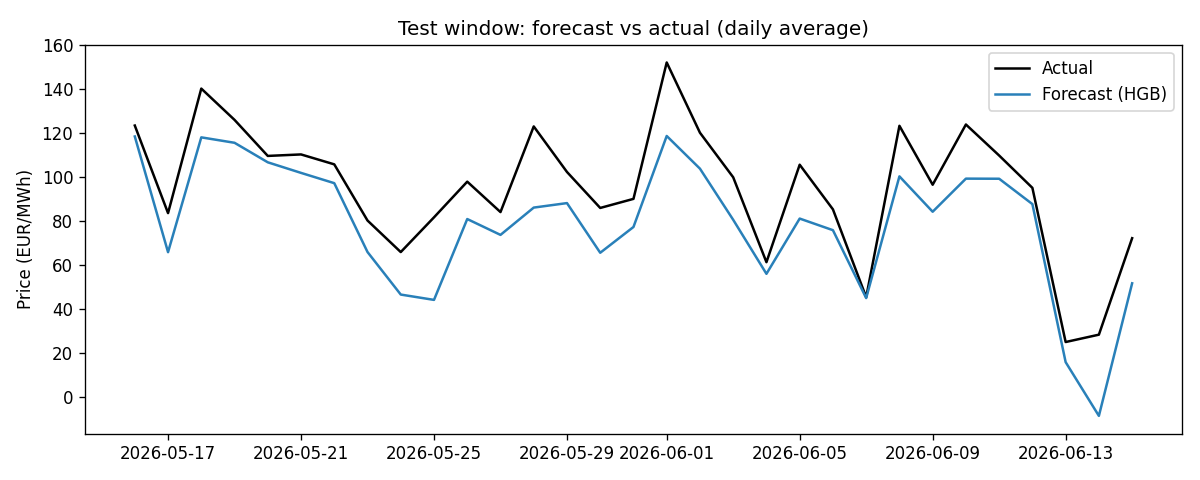

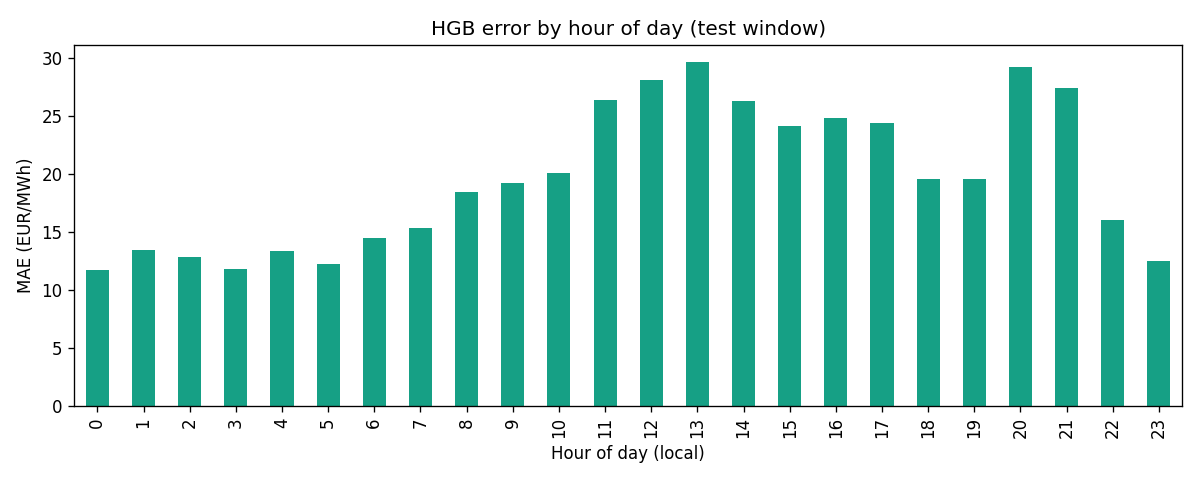

In [6]:
import config
from IPython.display import Image, display
display(Image(str(config.FIGURE_DIR / "forecast_vs_actual.png")))
display(Image(str(config.FIGURE_DIR / "mae_by_hour.png")))